<h1>MonReader: Single Frame Modelling (SFM): Model Training 2

<h3>Continuing SFM model training

In [1]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"

MODELS_DIR = PROJ_ROOT / "models"
SFM_MODELS_DIR = MODELS_DIR / "sfm"

In [2]:
# Base
import os
import pickle
import numpy as np
import pandas as pd

# Custom
from mrp_functions import *

Load the data, shuffle it, then create validation sets, using the custom functions from the previous notebook for repeatability:

In [3]:
pkl_data = load_pickle_data(SFM_DATA_DIR)

Loaded 4 pickle files:
['X_test', 'X_train', 'y_test', 'y_train']


In [4]:
X_train = pkl_data['X_train']
y_train = pkl_data['y_train']
X_test = pkl_data['X_test']
y_test = pkl_data['y_test']

In [5]:
X_train, y_train = shuffle_training_data(X_train, y_train)
X_train, X_val, y_train, y_val = create_validation_set(X_train, y_train)

In [6]:
# Inspect data: 
print("Training Data:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Class distribution: {np.bincount(y_train)}")

print("\nValidation Data:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")
print(f"  Class distribution: {np.bincount(y_val)}")

print("\nTest Data:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Class distribution: {np.bincount(y_test)}")

# Inspect pixel value ranges
print("\nPixel value ranges:")
print(f"  X_train: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"  X_val: [{X_val.min():.4f}, {X_val.max():.4f}]")
print(f"  X_test: [{X_test.min():.4f}, {X_test.max():.4f}]")

Training Data:
  X_train shape: (1913, 480, 270, 1)
  y_train shape: (1913,)
  Class distribution: [984 929]

Validation Data:
  X_val shape: (479, 480, 270, 1)
  y_val shape: (479,)
  Class distribution: [246 233]

Test Data:
  X_test shape: (597, 480, 270, 1)
  y_test shape: (597,)
  Class distribution: [307 290]

Pixel value ranges:
  X_train: [0.0000, 1.0000]
  X_val: [0.0000, 0.9961]
  X_test: [0.0000, 1.0000]


**'model_1'** from the last notebook had lots of overfitting as shown in the training vs validation loss curves divergence characteristics (see copy below). It's important to address this now.

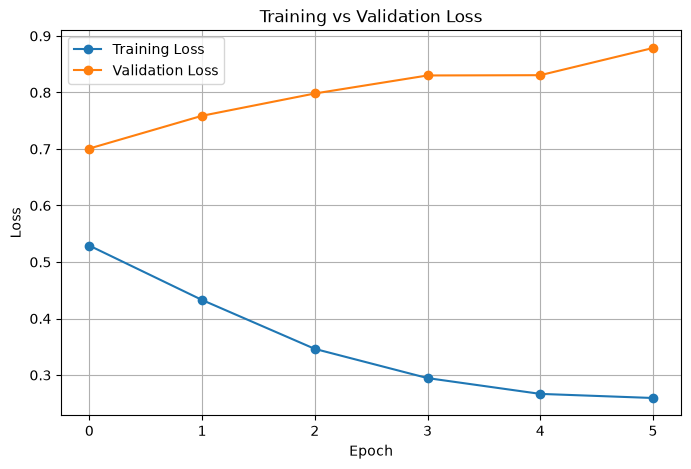

Let's create a new model with tweaks to address this overfitting:

Things to consider when creating the new model:

- **The output layer and loss don't match the problem cleanly**: Using Dense(2, sigmoid), with binary_crossentropy as the loss function, the targets are OneHot encoded despite the fact that we are dealing with a binary problem where the classes are mutually exclusive. Better to treat as binary rather than one hot i.e. [0,1] and [1,0]. Use 0 and 1. May be better to use: Dense(1, activation="sigmoid") with 'binary_crossentropy' for the loss.

- The very immediate overfitting shown in the loss curve is strange. **I don't think it is a pre-processing error** as the same steps are applied to both the train and test set, then randomisation of the train set occurs, followed by a random vaildation split. **Perhaps data augmentation could prove useful.**

- **Can a single frame from a clip show whether a page is being flipped, or are other frames of the same clip required to make the distinction?** Let's inspect some of the images to see if a human could make the distinction.

Quick inspection:

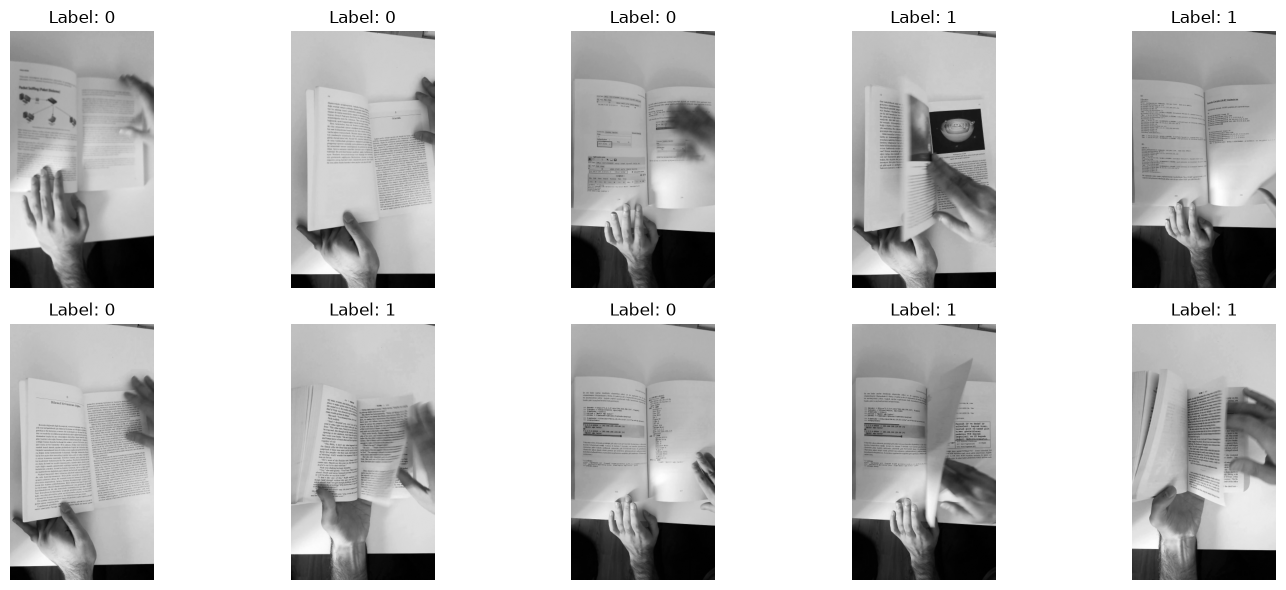

In [7]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = random.sample(range(len(X_train)), 10)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Labels: 0 = notflip, 1 = flip.

As seen in the images there are obvious instances where a page flip is observed and labelled as such. The things that makes a page flip distinct in the images is a *single page mid motion and at-an-angle*. There are a few instances where the way that the human is holding the book at an angle regardless of label which the model could see as a page flip. The key is that the page flip is near the centre of the image and sometimes involves a small covering of the human's hand(s).

**At this stage I think that there is enough information at a single frame level to make a distinction**, we just need to create a model that can do so.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt

In [9]:
train_model_2 = False

In [10]:
if train_model_2 == True:
    # This model looks simpler
    model_2 = Sequential([
        Conv2D(32,3,padding="same",activation="relu",input_shape=X_train.shape[1:]),
        BatchNormalization(),

        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Dropout(0.2),

        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        GlobalAveragePooling2D(),

        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3), # Increased slightly

        Dense(1, activation="sigmoid") # Changed as mentioned in the first bullet point above.
    ])

    model_2.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=["accuracy",
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall"),
                     tf.keras.metrics.AUC(name="auc")]
            )

    model_2.summary()

    early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=2
            )
    
    # Removed the 'to_categorical' parts as we have implemented Dense(1) above.

    trained_model_2 = model_2.fit(
            X_train,
            y_train,
            batch_size=64, # Batch size can affect training
            epochs=10,
            shuffle=True,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping]
        )
    

Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_history.pkl'


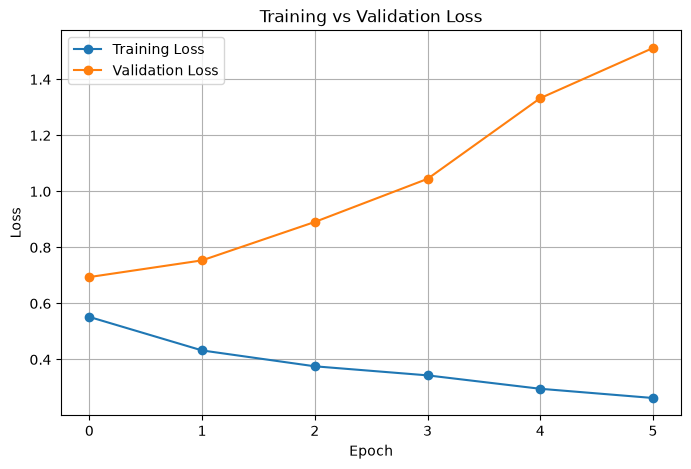

In [11]:
if train_model_2 == False:
    trained_model_2,trained_model_2_history =  load_model("model_2", SFM_MODELS_DIR)
    plot_training_history(trained_model_2_history, metric='loss')
else:
    trained_model_2_history = trained_model_2.history
    plot_training_history(trained_model_2_history, metric='loss')

Make some predictions:

Test set evaluation:
  loss: 0.6933549046516418
  compile_metrics: 0.4857621490955353

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


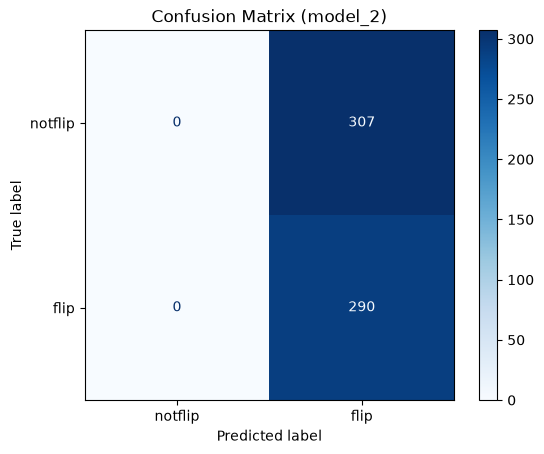

In [ ]:
from mrp_functions import evaluate_model

# Logic regarding re-execution without retraining
model_2_to_eval = model_2 if train_model_2 else trained_model_2

eval_results = evaluate_model(
    model_2_to_eval,
    X_test,
    y_test,
    class_names=('notflip', 'flip'),
    plot_name="model_2"
)

Exact same confusion matrix as model_1. 

Save the model:

In [ ]:
if train_model_2 == True:
    model_path = SFM_MODELS_DIR / 'model_2' # Don't worry about .pkl or .keras at the end, the function will take care of it.
    save_model(model_path, model_2, model_2.history)

Saved model to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2.keras'
Model size: 0.65 MB
History size: 0.0007 MB
Saved history to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_2_history.pkl'


<h3>